In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold, train_test_split, ShuffleSplit, cross_validate, ValidationCurveDisplay, LearningCurveDisplay
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    explained_variance_score,
    r2_score,
    root_mean_squared_error,
    PredictionErrorDisplay
)
from sklearn.pipeline import make_pipeline
import xgboost
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb
import plotly.graph_objects as go
import plotly.io as pio
import optuna

from sklearn.preprocessing import QuantileTransformer
from sklearn.compose import TransformedTargetRegressor

In [5]:
df_preprocessed = pd.read_csv('data/data_cleaned.csv')

df_models = pd.DataFrame(columns=[
            'Model Name', 'R2 train', 'R2 test',
            'RMSE train', 'RMSE test',
            'MAE train', 'MAE test',
            'EVS train', 'EVS test', 'CV mean score'
        ])
kf = KFold(n_splits=10, shuffle=True, random_state=42)

degree = 2
base_models = [
    (make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    ), 'LinearRegression/Polynomial - All Features'),
    (Ridge(), 'Ridge - All Features'),
    (Lasso(), 'Lasso - All Features'),
    (ElasticNet(), 'ElasticNet - All Features'),
    (GradientBoostingRegressor(), 'GradientBoosting - All Features'),
]

log_models = [
    (RandomForestRegressor(n_estimators=200, random_state=42), 'RandomForest - (All features)'),
    (XGBRegressor(eval_metric='rmse', use_label_encoder=False, random_state=42), 'XGBoost - (All features)'),
    (CatBoostRegressor(iterations=500, random_seed=42, learning_rate=0.5, depth=6, verbose=0), 'CatBoost Regressor - (All features)')
  #  (lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, objective='regression'), 'Light GBM - (All features)')
]

models = base_models + log_models + [
    (model, f"{name} (Log Price)") for model, name in log_models
]



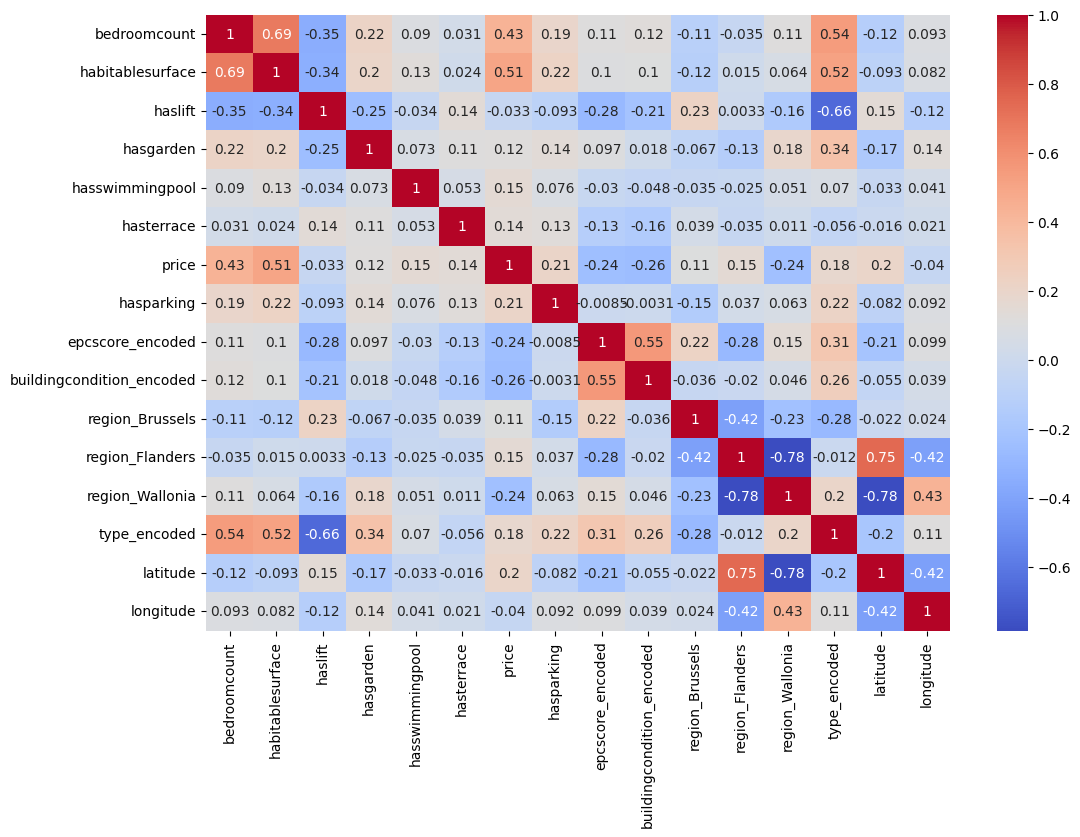

In [13]:
#corr = df_preprocessed[features + ['price']].corr()
corr = df_preprocessed.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [6]:
def split_train_test_set(df):
    
    """
    Splits the DataFrame into scaled train and test sets.

    Parameters:
        df (pd.DataFrame): DataFrame with features and 'price' as target.

    Returns:
        X_train, X_test, y_train, y_test, X_scaled
    """
    
    target_col = "price"
    X = df.drop(target_col, axis=1).values
    y = df[target_col].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
                X_scaled, y, test_size=0.2, random_state=42
            )
    return X_train, X_test, y_train, y_test, X_scaled

In [7]:
def array_to_df(X_scaled):
    # Recover feature names:
    feature_names = df_preprocessed.drop("price", axis=1).columns.tolist()
    #feature_names = df_preprocessed[top_selected_features].drop("price", axis=1).columns.tolist()
    # Convert back to DataFrame:
    return pd.DataFrame(X_scaled, columns=feature_names), feature_names

In [81]:

#def run_Models(df, obs, models, cv, results_df=None):

def run_Models(df_preprocessed, models):

    for model, name in models:
        log_target='Log Price' in name
        if log_target:
            df_preprocessed['price'] = np.log1p(df_preprocessed['price'])
            
            #y_train_mod = np.log1p(y_train)
            #y_test_mod = np.log1p(y_test)
            
        X_train, X_test, y_train, y_test, scaler = split_train_test_set(
            df_preprocessed)

        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        # if you trained on log price, invert prediction before metrics (if you want metrics in original scale)
        if log_target:
            df_preprocessed['price'] = np.expm1(df_preprocessed['price'])

        # Then calculate metrics with the original target scale
        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)

        rmse_train = root_mean_squared_error(y_train, y_pred_train)
        rmse_test = root_mean_squared_error(y_test, y_pred_test)

        mae_train = mean_absolute_error(y_train, y_pred_train)
        mae_test = mean_absolute_error(y_test, y_pred_test)

        evs_train = explained_variance_score(y_train, y_pred_train)
        evs_test = explained_variance_score(y_test, y_pred_test)

        # CV score
        X_full = scaler.transform(df_preprocessed.drop("price", axis=1).values)
        y_full = df_preprocessed["price"].values
        scores = cross_val_score(model, X_full, y_full, cv=kf)

        df_models.loc[len(df_models.index)] = [
            name,
            f'{r2_train:.3f}', f'{r2_test:.3f}',
            f'{rmse_train:.0f}\N{euro sign}', f'{rmse_test:.0f}\N{euro sign}',
            f'{mae_train:.0f}\N{euro sign}', f'{mae_test:.0f}\N{euro sign}',
            f'{evs_train:.2f}', f'{evs_test:.2f}',
            #f"Cross-val scores: {scores}"
            f"{scores.mean():.3f}"
        ]

    df_models.to_csv('data/model_eval.csv', sep='\t', encoding='utf-8', index=False, header=True)

    # Print results in a nice tabular form
    return df_models

run_Models(df_preprocessed, models)


,Model Name,R2 train,R2 test,RMSE train,RMSE test,MAE train,MAE test,EVS train,EVS test,CV mean score
0,LinearRegression/Polynomial - All Features,0.634,0.622,100087€,100451€,73704€,73936€,0.63,0.62,0.629
1,Ridge - All Features,0.520,0.509,114572€,114553€,85013€,84856€,0.52,0.51,0.517
2,Lasso - All Features,0.520,0.509,114572€,114553€,85013€,84856€,0.52,0.51,0.517
3,ElasticNet - All Features,0.482,0.472,119109€,118792€,89880€,89267€,0.48,0.47,0.479
4,GradientBoosting - All Features,0.695,0.674,91438€,93363€,67231€,68486€,0.69,0.67,0.682
5,RandomForest - (All features),0.961,0.710,32794€,87978€,23223€,62154€,0.96,0.71,0.723
6,XGBoost - (All features),0.826,0.736,69063€,83942€,49913€,59366€,0.83,0.74,0.740
7,CatBoost Regressor - (All features),0.852,0.728,63585€,85190€,46347€,59869€,0.85,0.73,0.739
8,RandomForest - (All features) (Log Price),0.965,0.746,0€,0€,0€,0€,0.97,0.75,0.723
9,XGBoost - (All features) (Log Price),0.838,0.764,0€,0€,0€,0€,0.84,0.76,0.740


In [82]:
# Plot R2 train/test as before

df_models['R2 train'] = df_models['R2 train'].astype(float)
df_models['R2 test'] = df_models['R2 test'].astype(float)

df_sorted = df_models.sort_values(by='R2 test', ascending=True)


fig = go.Figure(data=[
    go.Bar(
        name='R2 Train',
        x=df_sorted['Model Name'],
        y=df_sorted['R2 train'],
        text=df_sorted['R2 train'].round(3),
        textposition='outside',
    ),
    go.Bar(
        name='R2 Test',
        x=df_sorted['Model Name'],
        y=df_sorted['R2 test'],
        text=df_sorted['R2 test'].round(3),
        textposition='outside',
    )
])

fig.update_layout(
    template='plotly_dark',
    title='R2 Scores for Train and Test Sets (Ascending by Test Score)',
    title_x=0.5,
    yaxis_title='R2 Score',
    xaxis_tickangle=-45,   # inclinate 45 degrees
    barmode='group',       # Barrs
    height=600, 
    margin=dict(b=150)  
) 

fig.show()

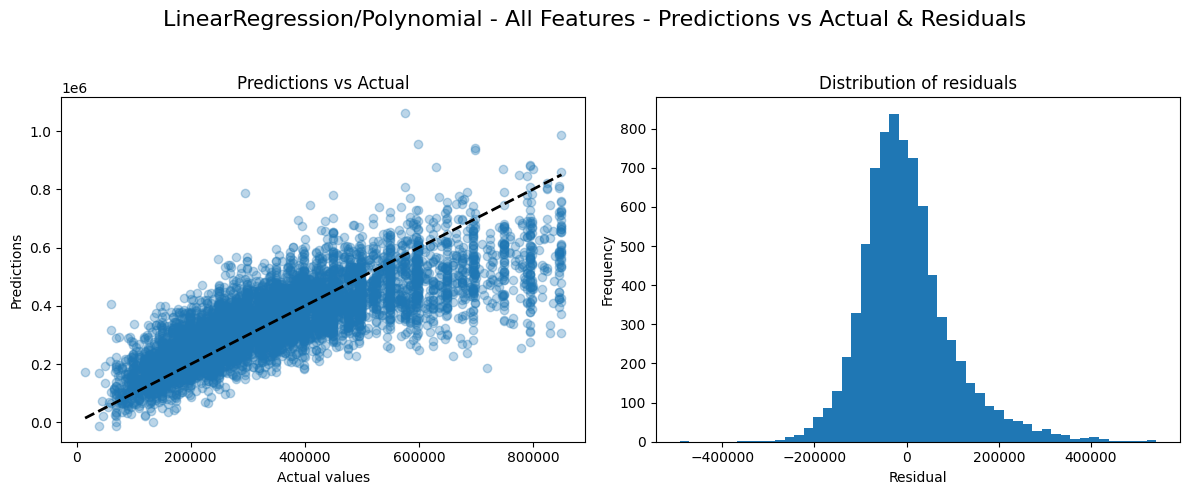

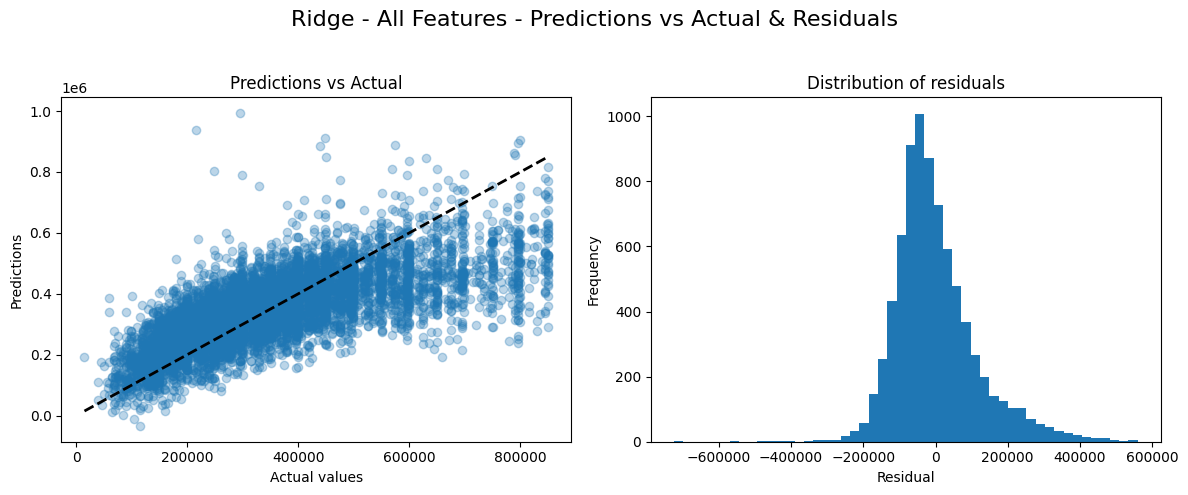

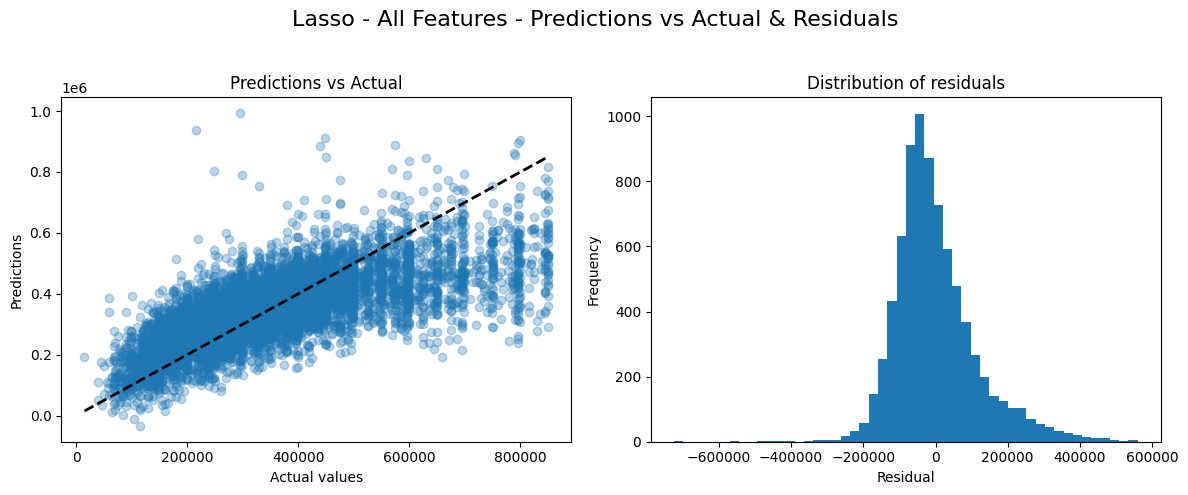

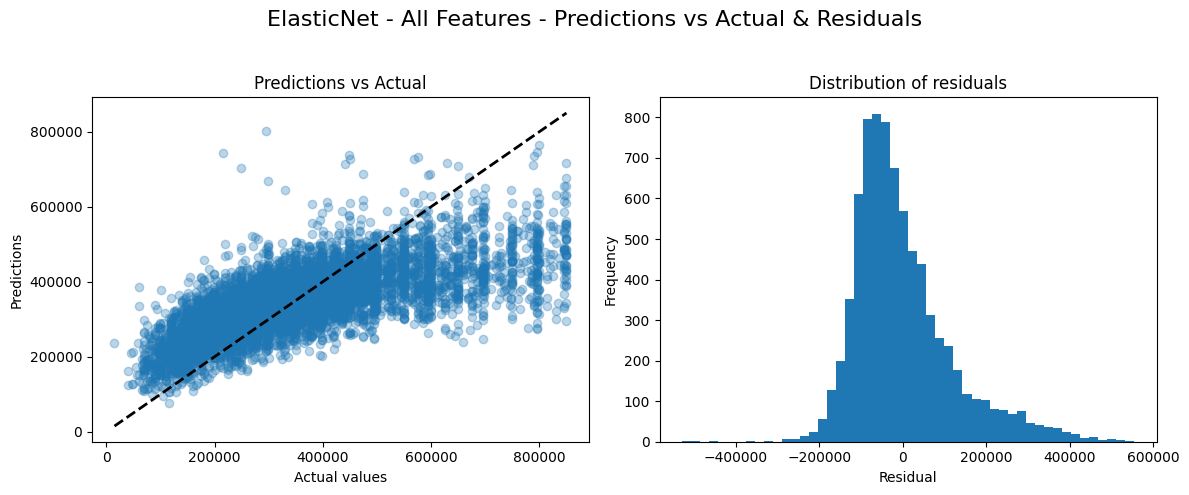

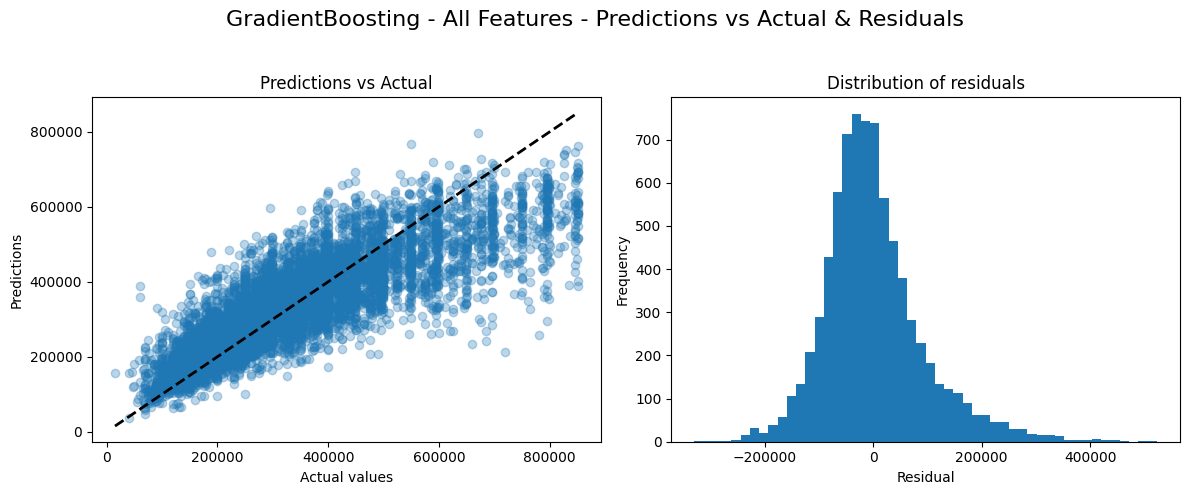

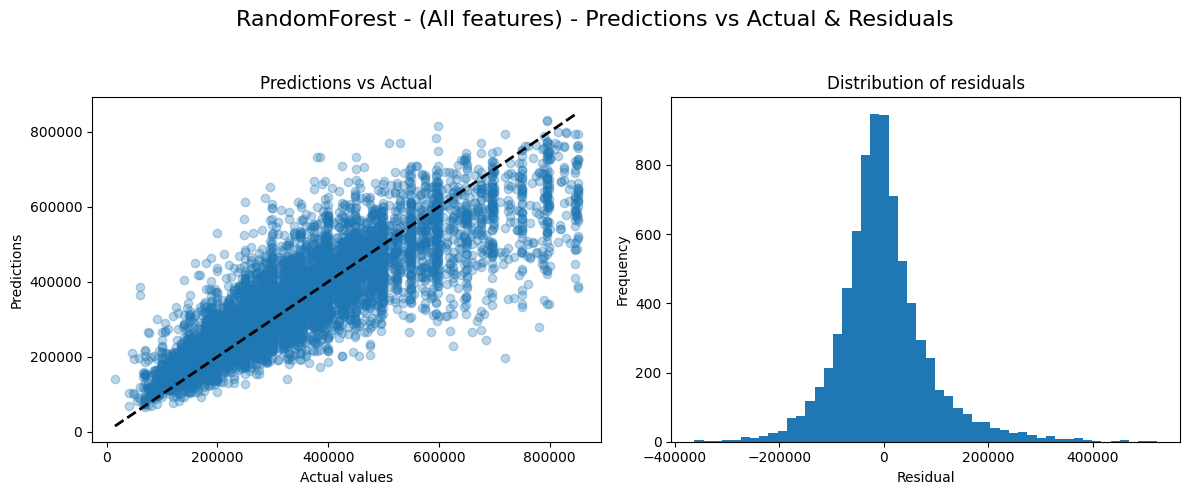

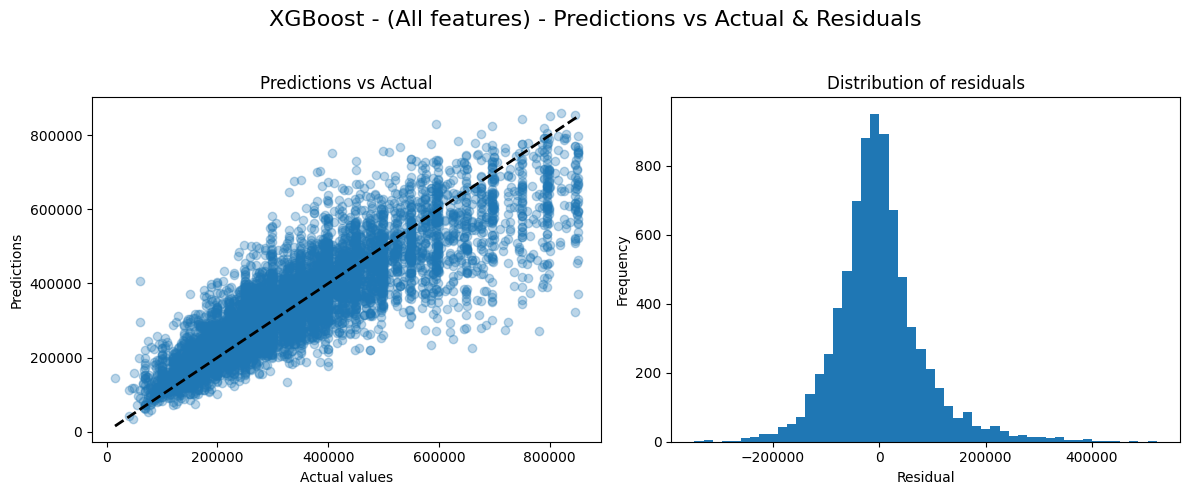

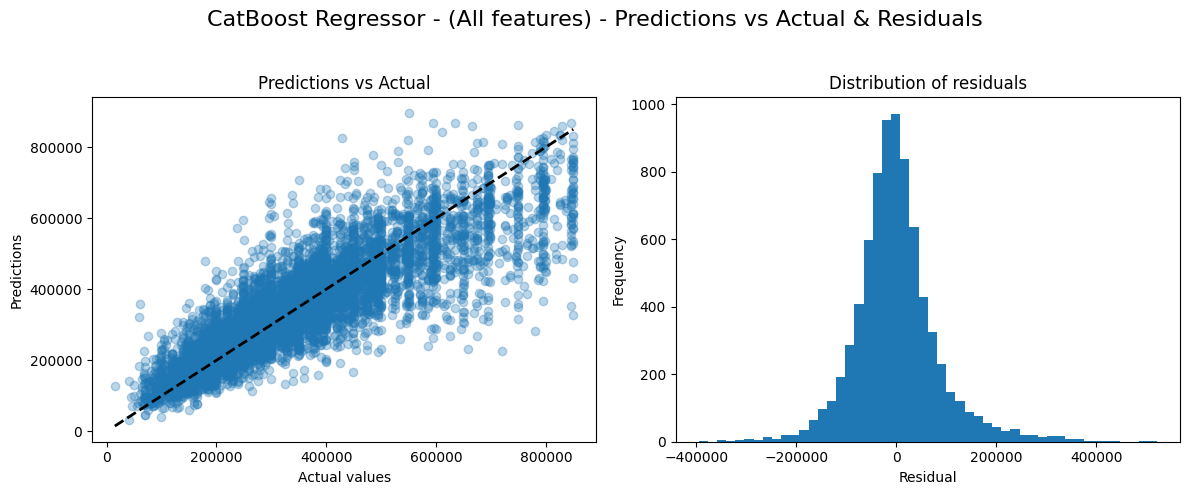

ValueError: autodetected range of [nan, nan] is not finite

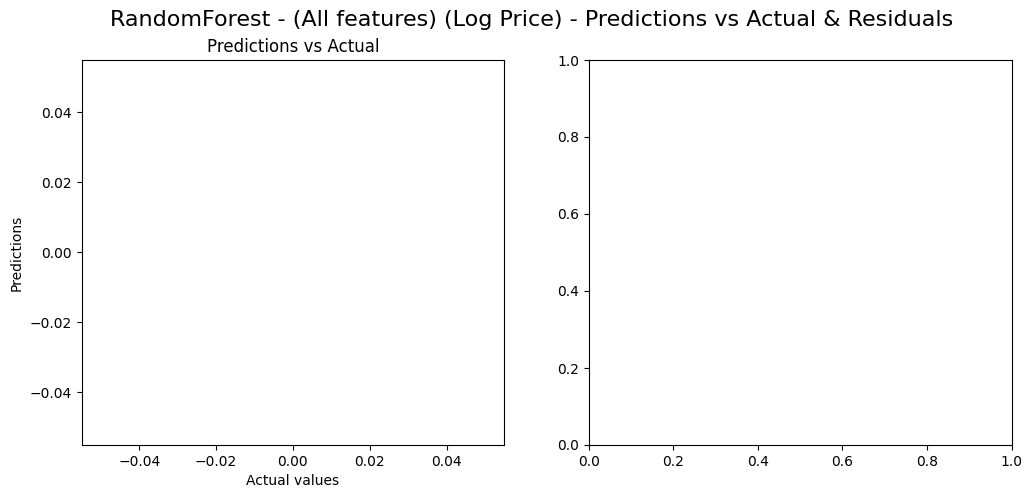

In [32]:
target_col = "price"
X = df_preprocessed.drop(target_col, axis=1).values
y = df_preprocessed[target_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )

for model, name in models:
    # Fit the model (if not fitted yet)
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # If this model was trained on log-price, revert predictions
    if 'Log Price' in name:
        y_pred = np.expm1(y_pred)
        y_true = np.expm1(y_test)
    else:
        y_true = y_test

    # Plot predictions vs actual
    plt.figure(figsize=(12, 5))
    plt.suptitle(f'{name} - Predictions vs Actual & Residuals', fontsize=16)

    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.3)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    plt.xlabel('Actual values')
    plt.ylabel('Predictions')
    plt.title('Predictions vs Actual')

    # Plot residuals histogram
    residuals = y_true - y_pred
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=50)
    plt.xlabel('Residual')
    plt.ylabel('Frequency')
    plt.title('Distribution of residuals')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [30]:
#def plot_feature_importances_multi(models, X_train, y_train, feature_names):
target_col = "price"
X = df_preprocessed.drop(target_col, axis=1).values
y = df_preprocessed[target_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )
    

""" Loop over multiple models and plot feature importances.
   """

    # Get importances and feature names
array_to_df(X_scaled)
feature_names = df_preprocessed.drop("price", axis=1).columns.tolist()
pd.DataFrame(X_scaled, columns=feature_names), feature_names

for model, name in models:
    print(f"\n Training {name} ...")
    model.fit(X_train, y_train)

    # Handle importances
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif 'xgboost' in name.lower():
        booster = model.get_booster()
        scores = booster.get_score(importance_type='weight')
        importances = np.array([scores.get(f'f{i}', 0.) for i in range(len(feature_names))])
    elif 'catboost' in name.lower():
        importances = model.get_feature_importance()
    else:
        print(f"No feature importances for {name}")
        continue

    sorted_idx = np.argsort(importances)
    importances_sorted = importances[sorted_idx]
    feature_names_sorted = np.array(feature_names)[sorted_idx]

    color = 'steelblue'
    if 'xgboost' in name.lower():
        color = 'darkorange'
    elif 'catboost' in name.lower():
        color = 'green'

    fig = go.Figure(go.Bar(
        x=importances_sorted,
        y=feature_names_sorted,
        orientation='h',
        marker_color=color
    ))

    fig.update_layout(
        template='plotly_dark',
        title=f'<b>Feature Importance: {name}',
        title_x=0.5,
        xaxis_title="Feature importance",
        yaxis_title='Feature',
        height=600
    )
    
    fig.show()





 Training LinearRegression/Polynomial - All Features ...
No feature importances for LinearRegression/Polynomial - All Features

 Training Ridge - All Features ...
No feature importances for Ridge - All Features

 Training Lasso - All Features ...
No feature importances for Lasso - All Features

 Training ElasticNet - All Features ...
No feature importances for ElasticNet - All Features

 Training GradientBoosting - All Features ...



 Training RandomForest - (All features) ...



 Training XGBoost - (All features) ...



 Training CatBoost Regressor - (All features) ...



 Training RandomForest - (All features) (Log Price) ...



 Training XGBoost - (All features) (Log Price) ...



 Training CatBoost Regressor - (All features) (Log Price) ...


## Closer look CatBoost Regressor

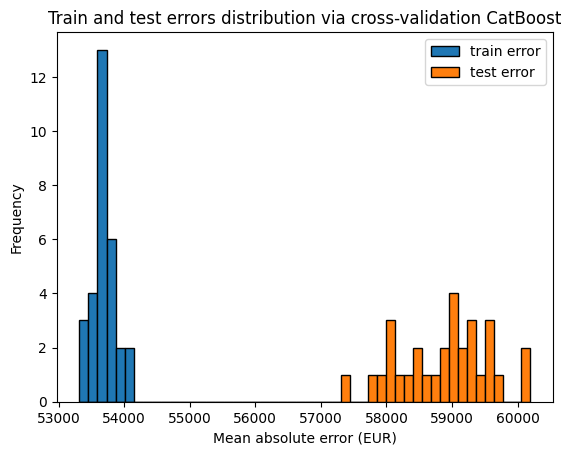

In [12]:
# Validation Curve

target_col = "price"
X = df_preprocessed.drop(target_col, axis=1).values
y = df_preprocessed[target_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )

regressor = CatBoostRegressor()

cv = ShuffleSplit(n_splits=30, test_size=0.2, random_state=0)
cv_results =  cross_validate(
    regressor,
    X_scaled,   # Or X_train, if you prefer
    df_preprocessed['price'].values,   # Your true y
    cv=cv,
    scoring="neg_mean_absolute_error",
    return_train_score=True,
    n_jobs=2,
)
cv_results = pd.DataFrame(cv_results)

scores = pd.DataFrame()
scores[["train error", "test error"]] = -cv_results[
    ["train_score", "test_score"]
]

scores.plot.hist(bins=50, edgecolor="black")
plt.xlabel("Mean absolute error (EUR)")
_ = plt.title("Train and test errors distribution via cross-validation CatBoost")

In [ ]:
"""# Validation Curve
# Verry long
max_depth = np.array([1, 5, 10, 15, 20, 25])
disp = ValidationCurveDisplay.from_estimator(
    regressor,
    X_scaled,
    df_preprocessed['price'].values,
    param_name="max_depth",
    param_range=max_depth,
    cv=cv,
    scoring="neg_mean_absolute_error",
    negate_score=True,
    std_display_style="errorbar",
    n_jobs=2,
)
_ = disp.ax_.set(
    xlabel="Maximum depth of decision tree",
    ylabel="Mean absolute error (EUR)",
    title="Validate curve for decision tree",
)"""

KeyboardInterrupt: 

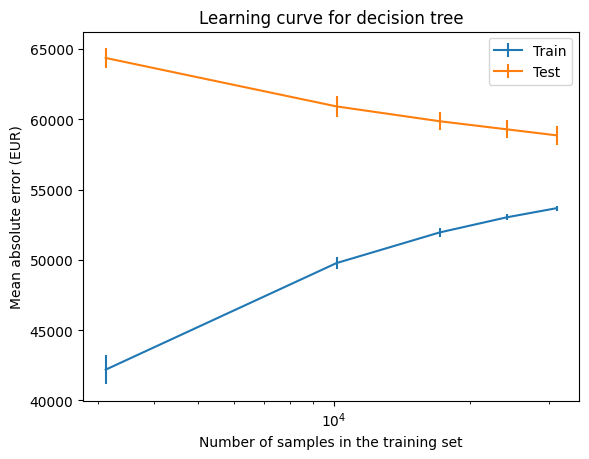

In [33]:
train_sizes = np.linspace(0.1, 1.0, num=5, endpoint=True)

display = LearningCurveDisplay.from_estimator(
    regressor,
    X_scaled,
    df_preprocessed['price'].values,
    train_sizes=train_sizes,
    cv=cv,
    score_type="both",  # both train and test errors
    scoring="neg_mean_absolute_error",
    negate_score=True,  # to use when metric starts with "neg_"
    score_name="Mean absolute error (EUR)",
    std_display_style="errorbar",
    n_jobs=2,
)
_ = display.ax_.set(xscale="log", title="Learning curve for decision tree")

Learning rate set to 0.070505
0:	learn: 0.9924080	total: 4.45ms	remaining: 4.45s
1:	learn: 0.9632014	total: 8.05ms	remaining: 4.02s
2:	learn: 0.9365553	total: 11.9ms	remaining: 3.97s
3:	learn: 0.9106059	total: 15.6ms	remaining: 3.89s
4:	learn: 0.8861127	total: 19.9ms	remaining: 3.95s
5:	learn: 0.8652070	total: 23.9ms	remaining: 3.96s
6:	learn: 0.8454464	total: 27.4ms	remaining: 3.89s
7:	learn: 0.8276135	total: 30.9ms	remaining: 3.83s
8:	learn: 0.8111743	total: 35.3ms	remaining: 3.88s
9:	learn: 0.7953616	total: 39.6ms	remaining: 3.92s
10:	learn: 0.7799605	total: 43.8ms	remaining: 3.93s
11:	learn: 0.7675835	total: 47.6ms	remaining: 3.92s
12:	learn: 0.7549696	total: 52.3ms	remaining: 3.97s
13:	learn: 0.7445797	total: 56.5ms	remaining: 3.98s
14:	learn: 0.7338885	total: 60.8ms	remaining: 3.99s
15:	learn: 0.7231114	total: 65.3ms	remaining: 4.01s
16:	learn: 0.7136996	total: 81.4ms	remaining: 4.7s
17:	learn: 0.7053723	total: 85.5ms	remaining: 4.67s
18:	learn: 0.6974952	total: 89.4ms	remaining:

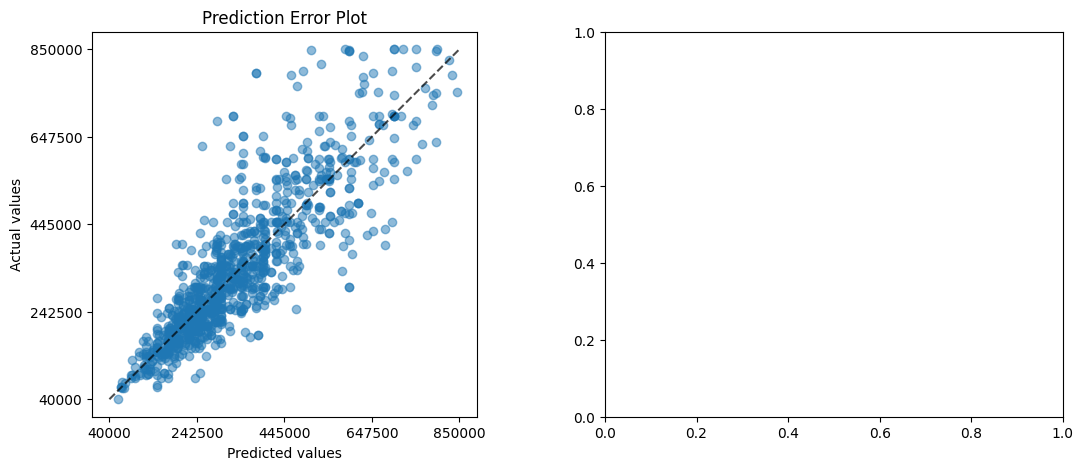

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import PredictionErrorDisplay
target_col = "price"
X = df_preprocessed.drop(target_col, axis=1).values
y = df_preprocessed[target_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )

regressor = CatBoostRegressor()

transformer = QuantileTransformer(
    n_quantiles=900, output_distribution="normal"
)
model_transformed_target = TransformedTargetRegressor(
    regressor=regressor, transformer=transformer
)


model_transformed_target.fit(X_train, y_train)
target_predicted = model_transformed_target.predict(X_test)

fig, axs = plt.subplots(ncols=2, figsize=(13, 5))

PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=target_predicted,
    kind="actual_vs_predicted",
    scatter_kwargs={"alpha": 0.5},
    ax=axs[0],
)

axs[0].axis("square")
axs[0].set_xlabel("Predicted values")
axs[0].set_ylabel("Actual values")
axs[0].set_title("Prediction Error Plot")

plt.show()

# Optuna

In [ ]:
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3 import A2C
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from optuna.visualization import plot_optimization_history, plot_param_importances
from typing import Any, Dict
import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as F
from optuna.visualization import plot_intermediate_values
from sklearn.datasets import fetch_california_housing

In [102]:

SEED = 13

# Example dataset — replace with yours
X, y = fetch_california_housing(return_X_y=True)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=SEED)
    
def objective(trial):
    # Suggest hyperparameters
    params = {
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_seed": SEED,
        "loss_function": "RMSE",
        "verbose": 0
    }

    model = CatBoostRegressor(**params)
    
    # You can use Pool if you want to use categorical features
    model.fit(X_train, y_train,
              eval_set=(X_valid, y_valid),
              early_stopping_rounds=50,
              verbose=0)
    
    preds = model.predict(X_valid)
    rmse = root_mean_squared_error(y_valid, preds)
    return rmse  # or any other metric you care about

study = optuna.create_study(
    direction="minimize",  # for RMSE you want to minimize
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

study.optimize(objective, n_trials=30, timeout=300)

print("Best trial:")
print(study.best_trial)

[I 2025-07-01 21:23:45,819] A new study created in memory with name: no-name-a8547348-cdab-4b1c-9adf-bcd69b150729
[I 2025-07-01 21:23:48,048] Trial 0 finished with value: 0.4560897395121579 and parameters: {'iterations': 800, 'depth': 5, 'learning_rate': 0.11011281694754152, 'l2_leaf_reg': 9.691742782386997}. Best is trial 0 with value: 0.4560897395121579.
[I 2025-07-01 21:23:51,922] Trial 1 finished with value: 0.46716565570906343 and parameters: {'iterations': 976, 'depth': 7, 'learning_rate': 0.032260569481843526, 'l2_leaf_reg': 7.97973863144362}. Best is trial 0 with value: 0.4560897395121579.
[I 2025-07-01 21:23:58,365] Trial 2 finished with value: 0.793328733594304 and parameters: {'iterations': 678, 'depth': 9, 'learning_rate': 0.001221208219026131, 'l2_leaf_reg': 3.6860452380026145}. Best is trial 0 with value: 0.4560897395121579.
[I 2025-07-01 21:24:00,104] Trial 3 finished with value: 0.7052286500977387 and parameters: {'iterations': 152, 'depth': 9, 'learning_rate': 0.008386

Best trial:
FrozenTrial(number=26, state=1, values=[0.4451344741471028], datetime_start=datetime.datetime(2025, 7, 1, 21, 25, 20, 906175), datetime_complete=datetime.datetime(2025, 7, 1, 21, 26, 3, 796471), params={'iterations': 994, 'depth': 10, 'learning_rate': 0.07913346075231958, 'l2_leaf_reg': 8.6778424929316}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'iterations': IntDistribution(high=1000, log=False, low=100, step=1), 'depth': IntDistribution(high=10, log=False, low=4, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'l2_leaf_reg': FloatDistribution(high=10.0, log=False, low=1.0, step=None)}, trial_id=26, value=None)


In [100]:
plot_optimization_history(study)

In [101]:
plot_intermediate_values(study)

[W 2025-07-01 21:23:35,736] You need to set up the pruning feature to utilize `plot_intermediate_values()`
